In [1]:
!pip install -q pandas numpy scikit-learn wfdb matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("WFDB:", wfdb.__version__)

Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1
WFDB: 4.3.1


In [4]:
!pip install -q ucimlrepo

In [11]:
# Fetch Cleveland Heart Disease dataset from UCI
heart_disease = fetch_ucirepo(id=45)

# Features
X = heart_disease.data.features

# Target
y = heart_disease.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (303, 13)
Target shape: (303, 1)


In [10]:
print("Feature columns:")
print(X.columns.tolist())

print("\nDataset information:")
X.info()

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [12]:
display(X.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [13]:
print("Missing values in each feature:")
print(X.isnull().sum())

Missing values in each feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [14]:
# Handle missing values using median imputation
X = X.copy()

for column in X.columns:
    X[column] = X[column].fillna(X[column].median())

print("Missing values after handling:")
print(X.isnull().sum())

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [15]:
# Convert target to binary
# 0 = No Disease
# 1, 2, 3, 4 = Disease

y_binary = (y.iloc[:, 0] > 0).astype(int)

print("Binary target distribution:")
print(y_binary.value_counts())

print("\nTarget mapping:")
print("0 = No Disease")
print("1 = Disease")

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64

Target mapping:
0 = No Disease
1 = Disease


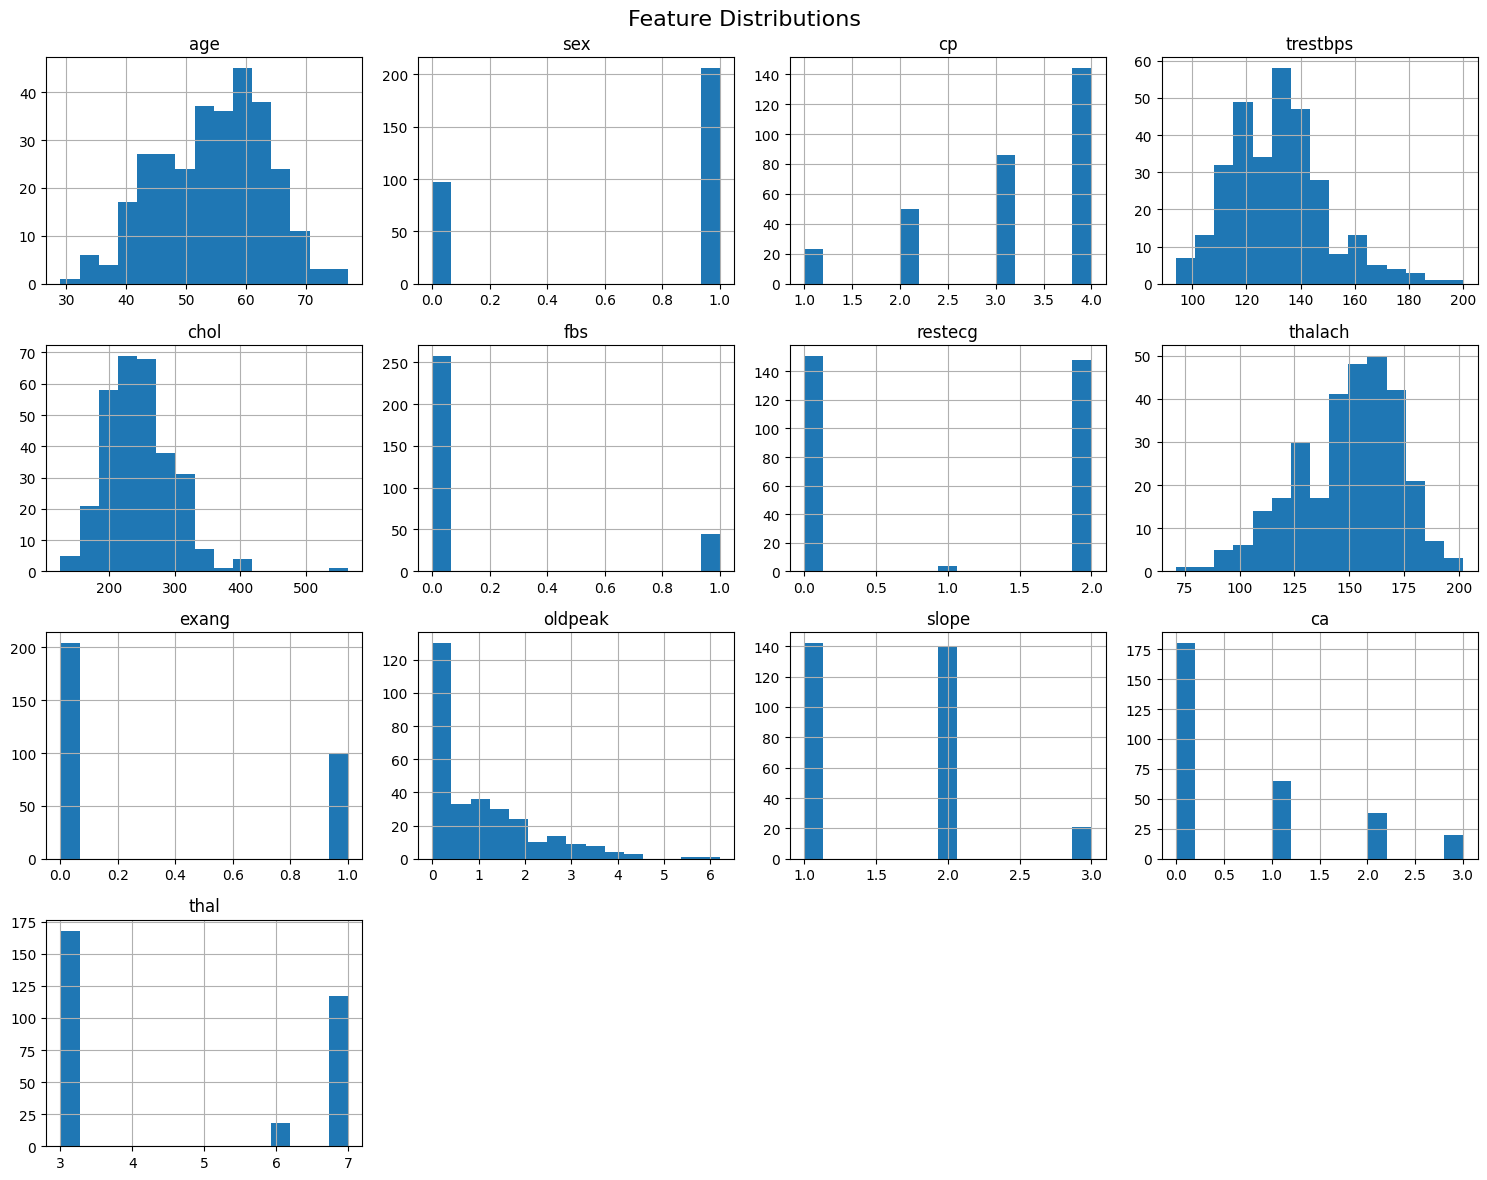

In [16]:
X.hist(figsize=(15, 12), bins=15)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

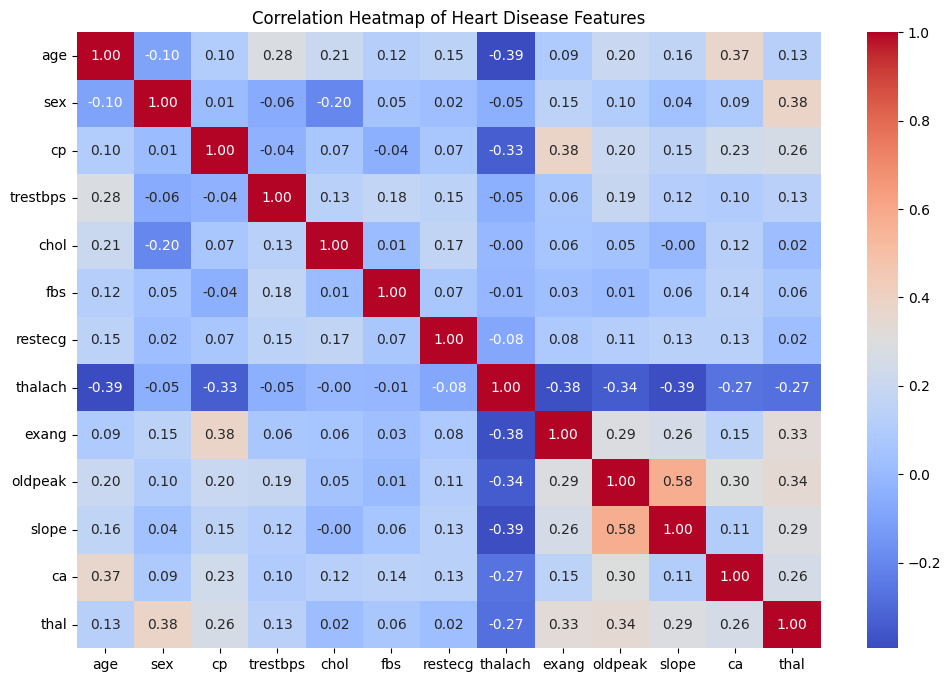

In [17]:
plt.figure(figsize=(12, 8))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Heart Disease Features")
plt.show()

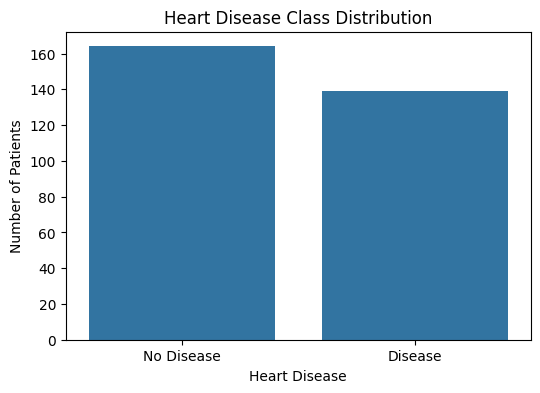

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y_binary)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [22]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.8688524590163934
Accuracy (%): 86.89 %


In [24]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9513


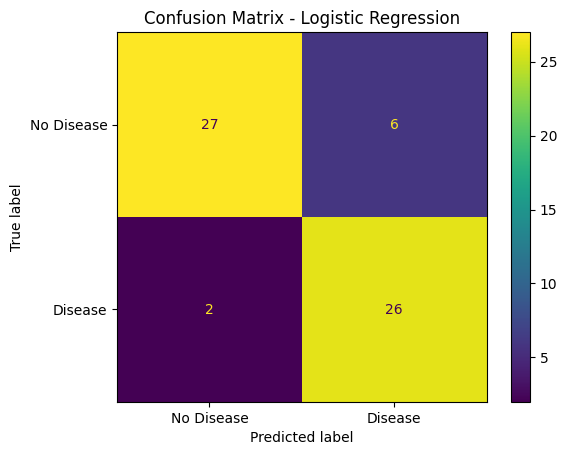

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [26]:
!pip install -q wfdb

In [27]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
!wget -r -N -c -np https://physionet.org/files/mitdb/1.0.0/

Streaming output truncated to the last 5000 lines.
Length: 5468 (5.3K) [application/octet-stream]
Saving to: ‘physionet.org/files/mitdb/1.0.0/223.atr’

physionet.org/files 100%[===================>]   5.34K  --.-KB/s    in 0s      

2026-09-20 19:54:14 (1.39 GB/s) - ‘physionet.org/files/mitdb/1.0.0/223.atr’ saved [5468/5468]

--2026-09-20 19:54:14--  https://physionet.org/files/mitdb/1.0.0/223.dat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1950000 (1.9M) [application/octet-stream]
Saving to: ‘physionet.org/files/mitdb/1.0.0/223.dat’

physionet.org/files 100%[===================>]   1.86M   200KB/s    in 9.4s    

2026-09-20 19:54:23 (202 KB/s) - ‘physionet.org/files/mitdb/1.0.0/223.dat’ saved [1950000/1950000]

--2026-09-20 19:54:23--  https://physionet.org/files/mitdb/1.0.0/223.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 258 [text/plain]
Saving to: ‘physionet.

In [29]:
data_path = "/content/physionet.org/files/mitdb/1.0.0/"

print("Files available:")
print(os.listdir(data_path)[:20])

Files available:
['228.atr', '219.dat', '115.atr', '213.dat', 'SHA256SUMS.txt', '109.xws', '111.xws', '233.hea', '203.dat', '101.hea', '123.xws', '115.dat', '119.xws', '220.dat', '228.hea', '112.xws', '220.hea', '105.atr', '114.xws', '215.atr']


In [30]:
record_path = data_path + "100"

# Read ECG signal
record = wfdb.rdrecord(record_path)

# Read annotations
annotation = wfdb.rdann(record_path, "atr")

print("Record loaded successfully!")
print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Number of annotations:", len(annotation.sample))

Record loaded successfully!
Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Number of annotations: 2274


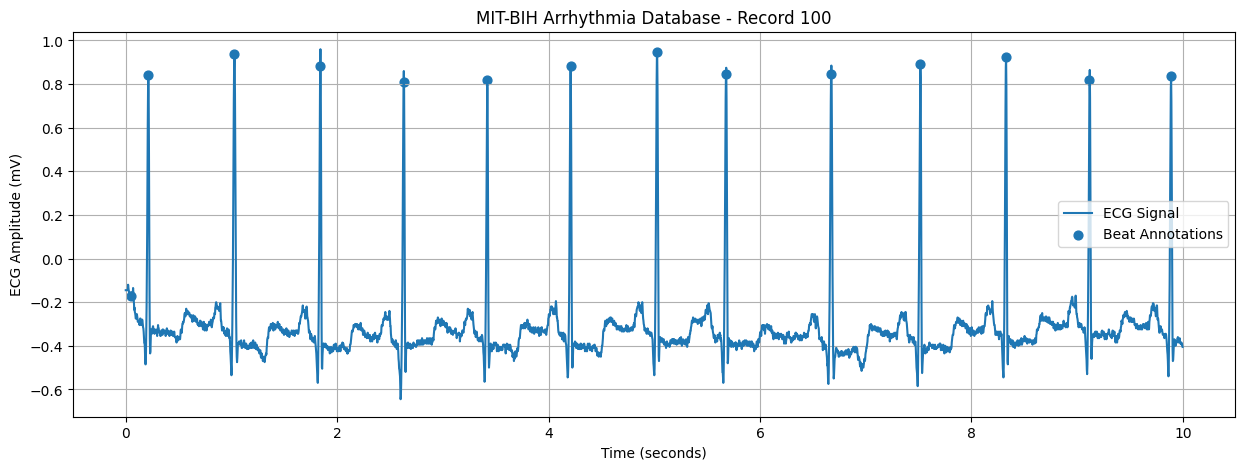

In [31]:
# Sampling frequency
fs = record.fs

# Plot first 10 seconds
duration = 10
num_samples = int(duration * fs)

signal = record.p_signal[:num_samples, 0]

time = np.arange(num_samples) / fs

plt.figure(figsize=(15, 5))

plt.plot(time, signal, label="ECG Signal")

# Select annotations within the plotted segment
ann_samples = annotation.sample
ann_symbols = annotation.symbol

mask = ann_samples < num_samples

plt.scatter(
    ann_samples[mask] / fs,
    signal[ann_samples[mask]],
    marker="o",
    s=40,
    label="Beat Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude (mV)")
plt.title("MIT-BIH Arrhythmia Database - Record 100")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
annotation_df = pd.DataFrame({
    "Sample": annotation.sample,
    "Time (seconds)": annotation.sample / fs,
    "Symbol": annotation.symbol
})

display(annotation_df.head(20))

,Sample,Time (seconds),Symbol
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


In [33]:
# Get annotation sample positions
beat_samples = annotation.sample

# Calculate RR intervals in seconds
rr_intervals = np.diff(beat_samples) / fs

print("Number of RR intervals:", len(rr_intervals))
print("First 10 RR intervals (seconds):")
print(rr_intervals[:10])

Number of RR intervals: 2273
First 10 RR intervals (seconds):
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [34]:
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
min_rr = np.min(rr_intervals)
max_rr = np.max(rr_intervals)

mean_hr = 60 / mean_rr

print("RR Interval Statistics")
print("----------------------")
print("Mean RR interval:", round(mean_rr, 4), "seconds")
print("Standard deviation:", round(std_rr, 4), "seconds")
print("Minimum RR interval:", round(min_rr, 4), "seconds")
print("Maximum RR interval:", round(max_rr, 4), "seconds")

print("\nEstimated Mean Heart Rate:", round(mean_hr, 2), "BPM")

RR Interval Statistics
----------------------
Mean RR interval: 0.7943 seconds
Standard deviation: 0.0506 seconds
Minimum RR interval: 0.1639 seconds
Maximum RR interval: 1.1306 seconds

Estimated Mean Heart Rate: 75.54 BPM


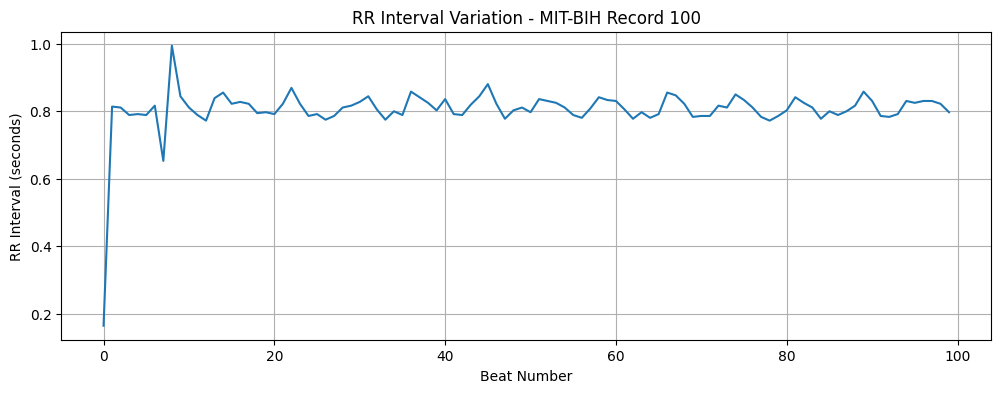

In [35]:
plt.figure(figsize=(12, 4))

plt.plot(rr_intervals[:100])

plt.xlabel("Beat Number")
plt.ylabel("RR Interval (seconds)")
plt.title("RR Interval Variation - MIT-BIH Record 100")
plt.grid(True)

plt.show()

In [36]:
clinical_note = """
Patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity.
He has a history of high blood pressure and high cholesterol.
Heart rate is elevated and the patient experiences occasional dizziness.
The physician recommends ECG monitoring and further cardiovascular evaluation.
"""

print(clinical_note)


Patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity.
He has a history of high blood pressure and high cholesterol.
Heart rate is elevated and the patient experiences occasional dizziness.
The physician recommends ECG monitoring and further cardiovascular evaluation.



In [37]:
import re

# Convert text to lowercase
text = clinical_note.lower()

# Extract words
tokens = re.findall(r'\b[a-z]+\b', text)

print("Tokens:")
print(tokens)

print("\nTotal number of tokens:", len(tokens))

Tokens:
['patient', 'is', 'a', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'reports', 'chest', 'discomfort', 'during', 'physical', 'activity', 'he', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'high', 'cholesterol', 'heart', 'rate', 'is', 'elevated', 'and', 'the', 'patient', 'experiences', 'occasional', 'dizziness', 'the', 'physician', 'recommends', 'ecg', 'monitoring', 'and', 'further', 'cardiovascular', 'evaluation']

Total number of tokens: 52


In [38]:
stopwords = {
    "the", "is", "a", "an", "and", "of", "with", "has",
    "he", "his", "to", "for", "in", "on", "during",
    "patient", "reports", "experiences"
}

filtered_tokens = [
    word for word in tokens
    if word not in stopwords
]

print("Filtered tokens:")
print(filtered_tokens)

Filtered tokens:
['year', 'old', 'male', 'presenting', 'chest', 'pain', 'shortness', 'breath', 'chest', 'discomfort', 'physical', 'activity', 'history', 'high', 'blood', 'pressure', 'high', 'cholesterol', 'heart', 'rate', 'elevated', 'occasional', 'dizziness', 'physician', 'recommends', 'ecg', 'monitoring', 'further', 'cardiovascular', 'evaluation']


In [39]:
from collections import Counter

word_frequency = Counter(filtered_tokens)

print("Word Frequency:")
for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:
chest : 2
high : 2
year : 1
old : 1
male : 1
presenting : 1
pain : 1
shortness : 1
breath : 1
discomfort : 1
physical : 1
activity : 1
history : 1
blood : 1
pressure : 1
cholesterol : 1
heart : 1
rate : 1
elevated : 1
occasional : 1
dizziness : 1
physician : 1
recommends : 1
ecg : 1
monitoring : 1
further : 1
cardiovascular : 1
evaluation : 1


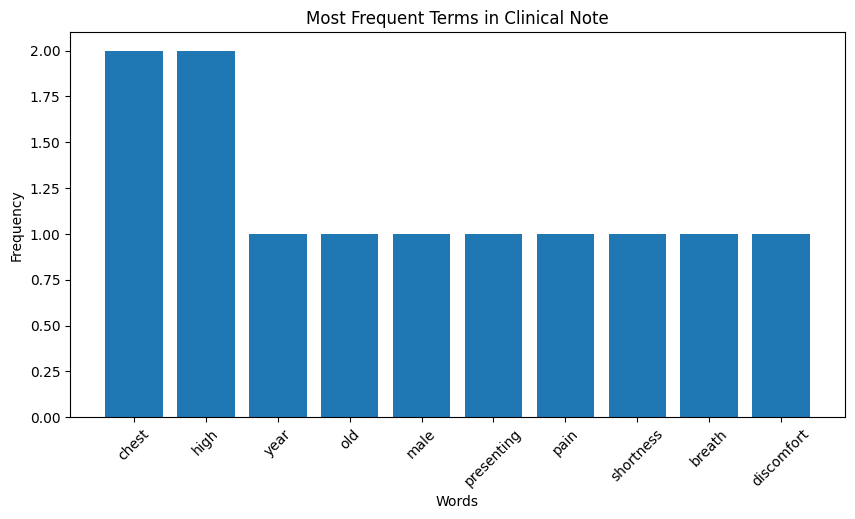

In [40]:
most_common_words = word_frequency.most_common(10)

words = [item[0] for item in most_common_words]
counts = [item[1] for item in most_common_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Most Frequent Terms in Clinical Note")
plt.xticks(rotation=45)

plt.show()

In [41]:
medical_terms = {
    "chest pain",
    "shortness of breath",
    "chest discomfort",
    "high blood pressure",
    "high cholesterol",
    "heart rate",
    "dizziness",
    "ecg",
    "cardiovascular"
}

found_terms = []

for term in medical_terms:
    if term in text:
        found_terms.append(term)

print("Key medical terms found:")
for term in found_terms:
    print("-", term)

Key medical terms found:
- heart rate
- shortness of breath
- high blood pressure
- high cholesterol
- ecg
- chest pain
- dizziness
- chest discomfort
- cardiovascular


In [42]:
print("Textual Data Summary")
print("--------------------")
print("Total tokens:", len(tokens))
print("Unique words:", len(set(tokens)))
print("Filtered words:", len(filtered_tokens))

print("\nKey medical terms:")
for term in found_terms:
    print("-", term)

Textual Data Summary
--------------------
Total tokens: 52
Unique words: 40
Filtered words: 30

Key medical terms:
- heart rate
- shortness of breath
- high blood pressure
- high cholesterol
- ecg
- chest pain
- dizziness
- chest discomfort
- cardiovascular


In [43]:
!pip install -q wfdb

In [44]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [45]:
!wget -r -N -c -np https://physionet.org/files/mitdb/1.0.0/

--2026-09-20 19:58:29--  https://physionet.org/files/mitdb/1.0.0/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/mitdb/1.0.0/index.html’

physionet.org/files     [ <=>                ]  22.87K  --.-KB/s    in 0.03s   

Last-modified header missing -- time-stamps turned off.
2026-09-20 19:58:30 (813 KB/s) - ‘physionet.org/files/mitdb/1.0.0/index.html’ saved [23416]

Loading robots.txt; please ignore errors.
--2026-09-20 19:58:30--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-09-20 19:58:30--  https://physionet.org/files/mitdb/1.0.0/mitdbdir/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 304 Not Modified
F

In [46]:
data_path = "/content/physionet.org/files/mitdb/1.0.0/"

files = os.listdir(data_path)

print("Number of files:", len(files))
print("First few files:")
print(files[:20])

Number of files: 208
First few files:
['228.atr', '219.dat', '115.atr', '213.dat', 'SHA256SUMS.txt', '109.xws', '111.xws', '233.hea', '203.dat', '101.hea', '123.xws', '115.dat', '119.xws', '220.dat', '228.hea', '112.xws', '220.hea', '105.atr', '114.xws', '215.atr']


In [47]:
record_path = data_path + "100"

record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, "atr")

print("Record loaded successfully!")
print("Sampling frequency:", record.fs, "Hz")
print("Signal shape:", record.p_signal.shape)
print("Signal names:", record.sig_name)
print("Number of annotations:", len(annotation.sample))

Record loaded successfully!
Sampling frequency: 360 Hz
Signal shape: (650000, 2)
Signal names: ['MLII', 'V5']
Number of annotations: 2274


In [48]:
print("Sampling frequency:", record.fs, "Hz")
print("Number of samples:", record.sig_len)
print("Number of signals:", record.n_sig)
print("Signal names:", record.sig_name)

print("\nAnnotation symbols:")
print(np.unique(annotation.symbol))

Sampling frequency: 360 Hz
Number of samples: 650000
Number of signals: 2
Signal names: ['MLII', 'V5']

Annotation symbols:
['+' 'A' 'N' 'V']


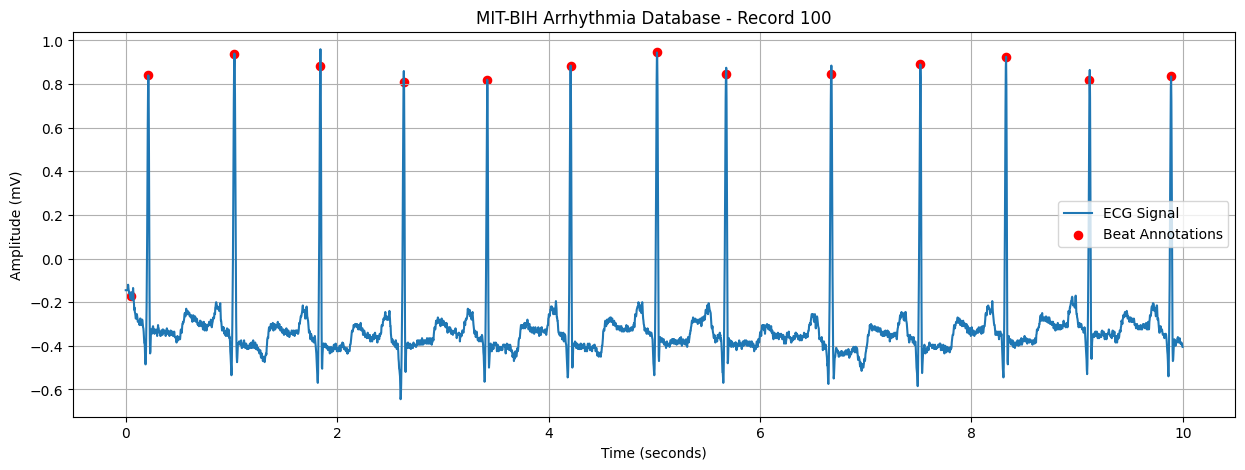

In [49]:
fs = record.fs

# First 10 seconds
duration = 10
num_samples = int(duration * fs)

ecg_signal = record.p_signal[:num_samples, 0]
time = np.arange(num_samples) / fs

# Select annotations within first 10 seconds
annotation_samples = annotation.sample
annotation_symbols = annotation.symbol

mask = annotation_samples < num_samples

plt.figure(figsize=(15, 5))

plt.plot(time, ecg_signal, label="ECG Signal")

plt.scatter(
    annotation_samples[mask] / fs,
    ecg_signal[annotation_samples[mask]],
    color="red",
    marker="o",
    s=35,
    label="Beat Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.title("MIT-BIH Arrhythmia Database - Record 100")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
annotation_df = pd.DataFrame({
    "Sample": annotation.sample,
    "Time (seconds)": annotation.sample / fs,
    "Symbol": annotation.symbol
})

display(annotation_df.head(20))

,Sample,Time (seconds),Symbol
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


In [51]:
beat_samples = annotation.sample

# Difference between consecutive beats
rr_intervals = np.diff(beat_samples) / fs

print("Number of RR intervals:", len(rr_intervals))
print("First 10 RR intervals:")
print(rr_intervals[:10])

Number of RR intervals: 2273
First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [52]:
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
min_rr = np.min(rr_intervals)
max_rr = np.max(rr_intervals)

mean_heart_rate = 60 / mean_rr

print("RR Interval Statistics")
print("----------------------")
print("Mean RR interval:", round(mean_rr, 4), "seconds")
print("Standard deviation:", round(std_rr, 4), "seconds")
print("Minimum RR interval:", round(min_rr, 4), "seconds")
print("Maximum RR interval:", round(max_rr, 4), "seconds")

print("\nEstimated Mean Heart Rate:", round(mean_heart_rate, 2), "BPM")

RR Interval Statistics
----------------------
Mean RR interval: 0.7943 seconds
Standard deviation: 0.0506 seconds
Minimum RR interval: 0.1639 seconds
Maximum RR interval: 1.1306 seconds

Estimated Mean Heart Rate: 75.54 BPM


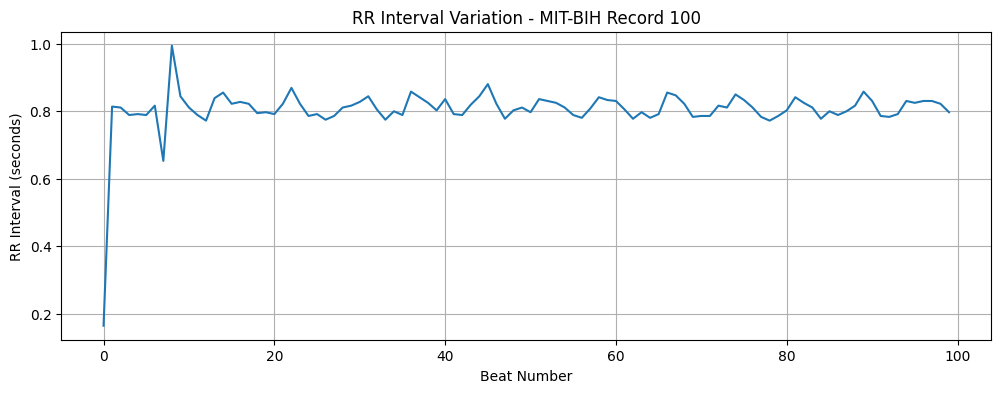

In [53]:
plt.figure(figsize=(12, 4))

plt.plot(rr_intervals[:100])

plt.xlabel("Beat Number")
plt.ylabel("RR Interval (seconds)")
plt.title("RR Interval Variation - MIT-BIH Record 100")
plt.grid(True)

plt.show()

In [54]:
clinical_note = """
Patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity.
He has a history of high blood pressure and high cholesterol.
Heart rate is elevated and the patient experiences occasional dizziness.
The physician recommends ECG monitoring and further cardiovascular evaluation.
"""

print(clinical_note)


Patient is a 58-year-old male presenting with chest pain and shortness of breath.
The patient reports chest discomfort during physical activity.
He has a history of high blood pressure and high cholesterol.
Heart rate is elevated and the patient experiences occasional dizziness.
The physician recommends ECG monitoring and further cardiovascular evaluation.



In [55]:
import re

text = clinical_note.lower()

tokens = re.findall(r'\b[a-z]+\b', text)

print("Tokens:")
print(tokens)

print("\nTotal number of tokens:", len(tokens))

Tokens:
['patient', 'is', 'a', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'reports', 'chest', 'discomfort', 'during', 'physical', 'activity', 'he', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'high', 'cholesterol', 'heart', 'rate', 'is', 'elevated', 'and', 'the', 'patient', 'experiences', 'occasional', 'dizziness', 'the', 'physician', 'recommends', 'ecg', 'monitoring', 'and', 'further', 'cardiovascular', 'evaluation']

Total number of tokens: 52


In [56]:
from collections import Counter

word_frequency = Counter(tokens)

print("Word Frequency:")
for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:
and : 4
patient : 3
the : 3
is : 2
a : 2
chest : 2
of : 2
high : 2
year : 1
old : 1
male : 1
presenting : 1
with : 1
pain : 1
shortness : 1
breath : 1
reports : 1
discomfort : 1
during : 1
physical : 1
activity : 1
he : 1
has : 1
history : 1
blood : 1
pressure : 1
cholesterol : 1
heart : 1
rate : 1
elevated : 1
experiences : 1
occasional : 1
dizziness : 1
physician : 1
recommends : 1
ecg : 1
monitoring : 1
further : 1
cardiovascular : 1
evaluation : 1


In [57]:
stopwords = {
    "the", "is", "a", "an", "and", "of", "with", "has",
    "he", "his", "to", "for", "in", "on", "during",
    "patient", "reports"
}

filtered_tokens = [
    word for word in tokens
    if word not in stopwords
]

filtered_frequency = Counter(filtered_tokens)

print("Most frequent meaningful terms:")
for word, count in filtered_frequency.most_common(10):
    print(word, ":", count)

Most frequent meaningful terms:
chest : 2
high : 2
year : 1
old : 1
male : 1
presenting : 1
pain : 1
shortness : 1
breath : 1
discomfort : 1


In [58]:
medical_terms = [
    "chest pain",
    "shortness of breath",
    "chest discomfort",
    "high blood pressure",
    "high cholesterol",
    "heart rate",
    "dizziness",
    "ecg",
    "cardiovascular"
]

found_terms = [
    term for term in medical_terms
    if term in text
]

print("Key medical terms found:")
for term in found_terms:
    print("-", term)

Key medical terms found:
- chest pain
- shortness of breath
- chest discomfort
- high blood pressure
- high cholesterol
- heart rate
- dizziness
- ecg
- cardiovascular


Image size: (256, 256)
Image mode: L


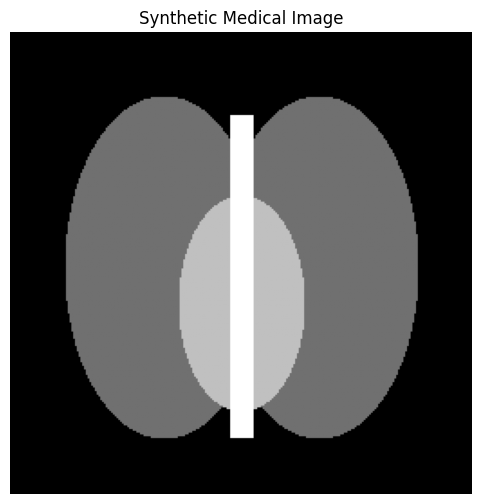

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Create a black background
size = 256
y, x = np.ogrid[:size, :size]

# Background gradient
image_array = np.ones((size, size)) * 30

# Simulate two lungs using elliptical regions
left_lung = ((x - 85) / 55) ** 2 + ((y - 130) / 95) ** 2 < 1
right_lung = ((x - 171) / 55) ** 2 + ((y - 130) / 95) ** 2 < 1

image_array[left_lung] = 100
image_array[right_lung] = 100

# Add a brighter central region representing the heart/mediastinum
heart = ((x - 128) / 35) ** 2 + ((y - 150) / 60) ** 2 < 1
image_array[heart] = 150

# Add a spine-like vertical structure
spine = (abs(x - 128) < 7) & (y > 45) & (y < 225)
image_array[spine] = 190

# Convert to image
medical_image = Image.fromarray(image_array.astype(np.uint8))

print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(medical_image, cmap="gray")
plt.title("Synthetic Medical Image")
plt.axis("off")
plt.show()

Original size: (256, 256)
Resized size: (128, 128)


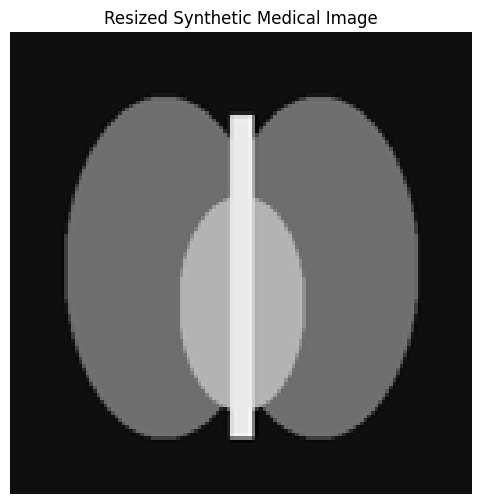

In [64]:
resized_image = medical_image.resize((128, 128))

print("Original size:", medical_image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(6, 6))
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Synthetic Medical Image")
plt.axis("off")
plt.show()

In [66]:
print("Image Metadata")
print("----------------")
print("Format:", medical_image.format)
print("Mode:", medical_image.mode)
print("Original Size:", medical_image.size)
print("Resized Size:", resized_image.size)

Image Metadata
----------------
Format: None
Mode: L
Original Size: (256, 256)
Resized Size: (128, 128)


In [67]:
## Multimodal Healthcare Data Integration

## The datasets used in this assignment represent different types of healthcare information.

## The UCI Cleveland Heart Disease dataset provides structured tabular information such as age, sex, blood pressure, cholesterol, chest pain type, and maximum heart rate. These features can be used to estimate the presence of heart disease using machine learning models.

## The MIT-BIH Arrhythmia Database provides ECG signal data and expert beat annotations. ECG-derived features such as RR intervals, heart rate, and heart-rate variability can provide additional information about cardiac activity.

## Clinical notes provide unstructured textual information about symptoms, medical history, and physician observations. Natural Language Processing (NLP) techniques can be used to extract important medical terms and symptoms from these notes.

## In a future multimodal healthcare system, these different data sources could be combined into a single model. Tabular features could be processed using a machine learning model, ECG signals could be processed using signal-processing or deep-learning techniques, and clinical notes could be processed using NLP or language models.

## The resulting feature representations could then be combined using feature-level or decision-level fusion. This multimodal approach could provide a more comprehensive representation of a patient's condition than using only one type of data.

Format: PNG
Mode: L
Size: (256, 256)


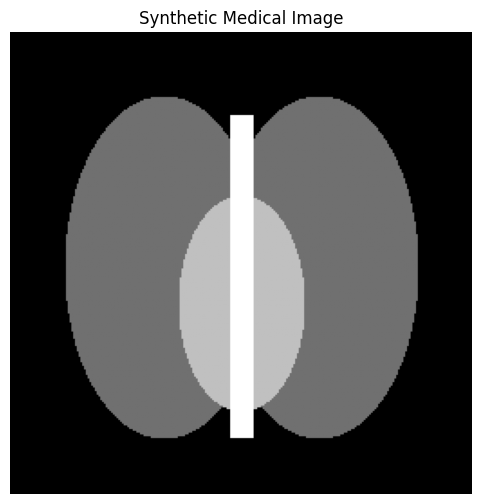

Resized Size: (128, 128)


In [68]:
medical_image.save("synthetic_medical_image.png")

loaded_image = Image.open("synthetic_medical_image.png")

print("Format:", loaded_image.format)
print("Mode:", loaded_image.mode)
print("Size:", loaded_image.size)

plt.figure(figsize=(6, 6))
plt.imshow(loaded_image, cmap="gray")
plt.title("Synthetic Medical Image")
plt.axis("off")
plt.show()

resized_image = loaded_image.resize((128, 128))

print("Resized Size:", resized_image.size)